# 01 - Solar Radiation: Advanced Surface Sensors

**What it computes.** Cumulative shortwave solar irradiation (kWh/m2) over a
time window, accounting for building/terrain shadowing. The standard model
returns a 512x512 ground grid; the **advanced** surface mode instead
synthesizes a sensor grid directly on building **facades** and **roofs** -
the surfaces that actually drive PV yield, overheating and daylight.

**Advanced inputs gained**

* `analysis-surfaces`: `"facades"` | `"roofs"` | `"all"` - auto-synthesize a
  UV sensor grid on the matching triangles of every mesh in `geometries`.
* `surface-grid-size` (m, default 2.0) - cell pitch. `surface-offset` (m,
  default 0.1) - lift off the surface to avoid self-shadowing.
* `partial-cells` (default true) + `min-coverage` - clip boundary cells to
  the surface outline and prune thin slivers.
* `sensor-points` / `sensor-normals` - bring-your-own measurement locations.

**When to use.** Facade PV siting, building-envelope solar gains, roof PV
potential - anywhere you need irradiance *on the building*, not on the street.

## Setup

In [1]:
# --- Setup: auth, base URL, geometry (self-contained) -----------------------
# Set your key in the environment first:  export INFRARED_API_KEY=...
# Optionally load a .env file (pip install python-dotenv):
try:
    from dotenv import load_dotenv

    load_dotenv()
except Exception:
    pass

import os

# Default base URL = STAGING (host root, NO /v2) where advanced features deploy
# first. For production set INFRARED_BASE_URL=https://api.infrared.city/v2
os.environ.setdefault("INFRARED_BASE_URL", "https://api-test.infrared.city")

import numpy as np
import ir_advanced as ia
import ir_render as ir

print("base URL :", ia.base_url())
client = ia.make_client()
buildings = ia.fetch_buildings(
    client, ia.VIENNA_KARLSPLATZ, "karlsplatz_buildings.json"
)
print(f"buildings: {len(buildings)} (Vienna Karlsplatz AOI, fetched via SDK + cached)")

base URL : https://api-test.infrared.city
buildings: 132 (Vienna Karlsplatz AOI, fetched via SDK + cached)


In [2]:
# Weather: nearest TMY file to the AOI, filtered to the analysis window.
from infrared_sdk.models import TimePeriod, Location

weather_id = ia.fetch_weather_identifier(client)
print("weather file:", weather_id)

weather file: AUT_WI_Wien-Innere.Stadt.110340_TMYx.2009-2023


## Standard run (baseline grid)

First the ordinary 512x512 ground grid - no advanced fields. We build the
request with the SDK's own model so the weather arrays are correct, then POST
it through the direct-API helper (the advanced runs reuse the same body).

In [3]:
from infrared_sdk.analyses.types import (
    SolarRadiationModelRequest,
    BaseAnalysisPayload,
    AnalysesName,
)

# Summer afternoon window (single day) for a fast baseline.
tp = TimePeriod(
    start_month=7, start_day=15, start_hour=9, end_month=7, end_day=15, end_hour=17
)
loc = Location(latitude=ia.VIENNA_LAT, longitude=ia.VIENNA_LON)
wp = client.weather.filter_weather_data(identifier=weather_id, time_period=tp)


def sr_body():
    """Baseline solar-radiation body with correct weather arrays + geometry."""
    b = SolarRadiationModelRequest.from_weatherfile_payload(
        BaseAnalysisPayload(analysis_type=AnalysesName.solar_radiation), loc, tp, wp
    ).to_dict()
    b["latitude"] = ia.VIENNA_LAT
    b["longitude"] = ia.VIENNA_LON
    b["geometries"] = buildings
    return b


grid_res, info = ia.run_job("solar-radiation", sr_body(), label="grid")
grid = np.array(grid_res["output"], dtype=float)
print(
    "grid shape:",
    grid.shape,
    "| min/max-legend:",
    grid_res.get("min-legend"),
    grid_res.get("max-legend"),
)

[solar-radiation/grid] Succeeded in 1.9s  keys=['max-legend', 'min-legend', 'output']
grid shape: (512, 512) | min/max-legend: 0 6


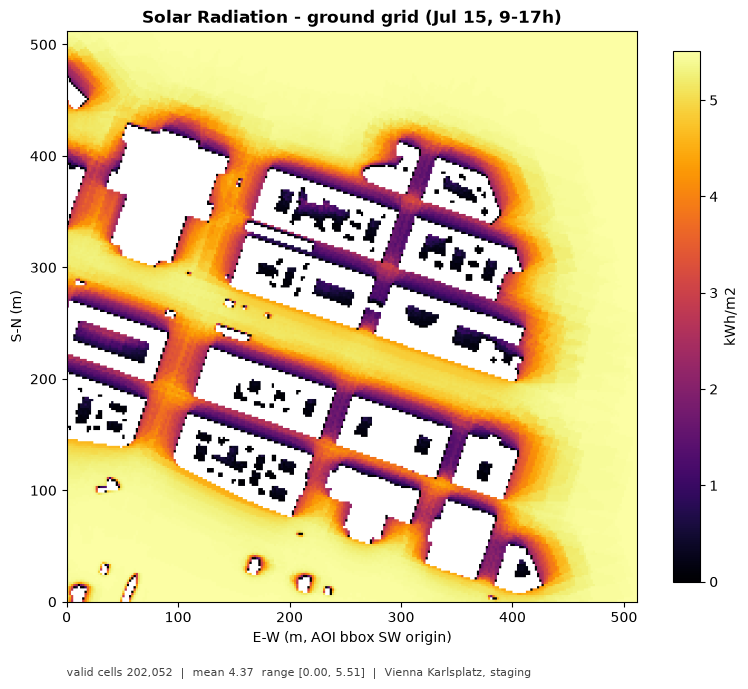

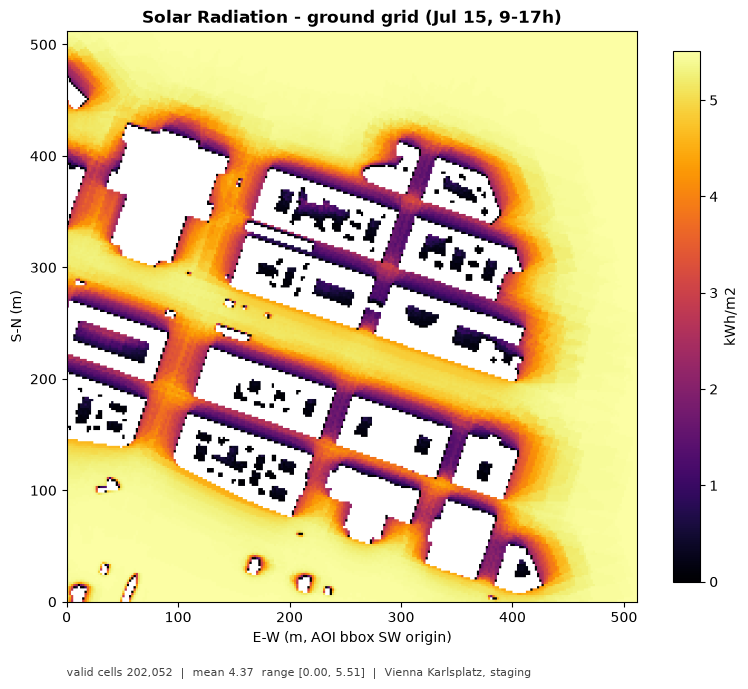

In [4]:
fig, ax = ir.grid_heatmap(
    grid,
    title="Solar Radiation - ground grid (Jul 15, 9-17h)",
    cbar_label="kWh/m2",
    cmap="inferno",
    crop=True,
    note="Vienna Karlsplatz, staging",
)
fig

## Advanced run 1 - facade sensor synthesis

Add `analysis-surfaces:"facades"`. The worker finds the near-vertical
triangles of every building and lays a UV grid on them. The result is no
longer an `output` grid - it's a **`surfaces`** map (one frame per surface
region) plus per-building `aggregates`.

In [5]:
body = sr_body()
body["analysis-surfaces"] = "facades"
body["surface-grid-size"] = 4.0  # 4 m cell pitch
body["surface-offset"] = 0.1
body["partial-cells"] = True  # clip boundary cells to the outline
body["min-coverage"] = 0.25  # drop cells < 25% inside the surface

fac_res, info = ia.run_job("solar-radiation", body, label="facades")
print("frames:", len(fac_res["surfaces"]), "| sensors:", fac_res["sensor-count"])

[solar-radiation/facades] Succeeded in 1.4s  keys=['aggregates', 'max-legend', 'min-legend', 'sensor-count', 'surfaces']  sensors=44276
frames: 2724 | sensors: 44276


### Result payload, described

The surface response has exactly these top-level keys:
`surfaces`, `aggregates`, `min-legend`, `max-legend`, `sensor-count`
(**no** `output` grid).

* **`surfaces`** - `{ "<building-uuid>/<region-idx>": frame }`. Each **frame**
  is a planar UV grid:
  * `origin`, `u-axis`, `v-axis` - the cell-(0,0) corner and the two in-plane
    unit axes.
  * `grid-size` - cell pitch (m). `nu`, `nv` - cell counts along u / v.
  * `values` - `nu*nv` row-major (`iv` outer, `iu` inner); `null` = cell
    outside the surface outline (the worker still reports the full grid shape).
  * `cell-area`, `cell-tris` - per-cell area fraction `(0,1]` and the exact
    clipped footprint (flat world-coord triangle list), both aligned 1:1 with
    `values`.
  * `area`, `mean`, `peak` - per-frame summary.
* **`aggregates.buildings.<uuid>`** - `{area, mean, peak}` area-weighted across
  that building's frames.
* **`sensor-count`** - total non-null cells (== `min-legend`/`max-legend` span
  the colorbar).

Each frame also carries two arrays **aligned 1:1 with `values`** (same length
`nu*nv`, `null` exactly where `values` is `null`):

* **`cell-area`** - the in-surface area fraction of each kept cell, in `(0, 1]`
  (`1.0` = full cell, `< 1.0` = a boundary cell clipped by `partial-cells`).
* **`cell-tris`** - the cell's exact **clipped footprint** as a flat
  `[x, y, z, ...]` triangle list in world coordinates (`len % 9 == 0`).

So you do not need any index math: render each cell straight from its
`cell-tris` polygon. `reconstruct_cells()` does exactly that, returning a
colored triangle soup `(tris, values, normals)` ready for a 3D mesh. (For a
cell missing tris it falls back to the full grid quad, treating `origin` as the
cell-(0,0) **centre** and iterating `values` in wire order `k = iv*nu + iu`.)

> `partial-cells` clipping is reflected directly on the wire now (since the
> `cell-tris` / `cell-area` serialization landed): boundary cells come back as
> real clipped polygons, not full squares, so the mesh render has smooth edges.

In [6]:
import json

# Pretty-print one frame (arrays trimmed) + this building's aggregate.
fk = next(iter(fac_res["surfaces"]))
frame = fac_res["surfaces"][fk]
print("frame key:", fk)
_trim = {"values", "cell-area", "cell-tris"}
print(
    json.dumps(
        {
            k: (v[:6] + ["...(%d total)" % len(v)] if k in _trim else v)
            for k, v in frame.items()
        },
        indent=2,
        default=float,
    )
)
bid = fk.split("/")[0]
print(
    "\naggregates for building",
    bid,
    ":",
    json.dumps(fac_res["aggregates"]["buildings"].get(bid, {}), default=float),
)

frame key: 11155/0
{
  "origin": [
    1.6321067097250321,
    268.6121667244433,
    2.0
  ],
  "u-axis": [
    -0.2860372460124409,
    -0.9582185000789843,
    0.0
  ],
  "v-axis": [
    0.0,
    0.0,
    1.0
  ],
  "grid-size": 4.0,
  "nu": 1,
  "nv": 8,
  "values": [
    0.80224609375,
    0.9716796875,
    1.1435546875,
    1.1982421875,
    1.5546875,
    1.6728515625,
    "...(8 total)"
  ],
  "area": 128.0,
  "mean": 1.38092041015625,
  "peak": 1.8896484375,
  "cell-area": [
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    "...(8 total)"
  ],
  "cell-tris": [
    [
      2.20418119430542,
      270.5285949707031,
      0.0,
      1.4041781425476074,
      267.8486022949219,
      0.0,
      1.504178524017334,
      268.1836242675781,
      4.0,
      2.20418119430542,
      270.5285949707031,
      0.0,
      1.504178524017334,
      268.1836242675781,
      4.0,
      2.20418119430542,
      270.5285949707031,
      4.0,
      1.4041781425476074,
      267.8486022949

## Render - colored surface mesh on the building geometry

Render every kept cell from its exact `cell-tris` clipped footprint as a
Lambert-shaded colored triangle mesh (edges off) over a faint building context.
This is the headline view: real per-facade irradiance with smooth boundary
cells, not a scatter cloud or blocky squares.

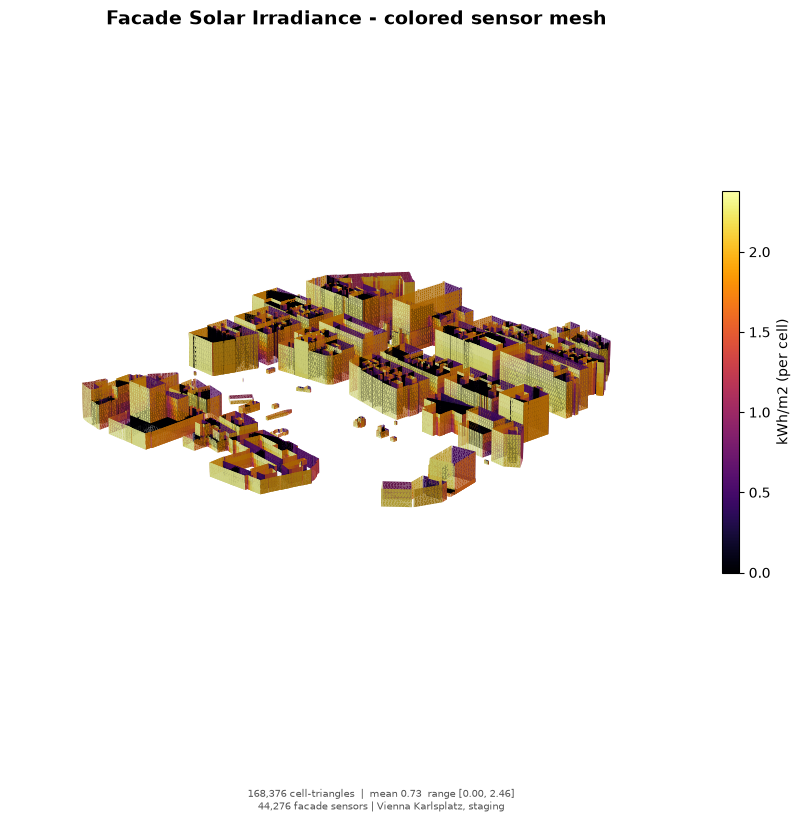

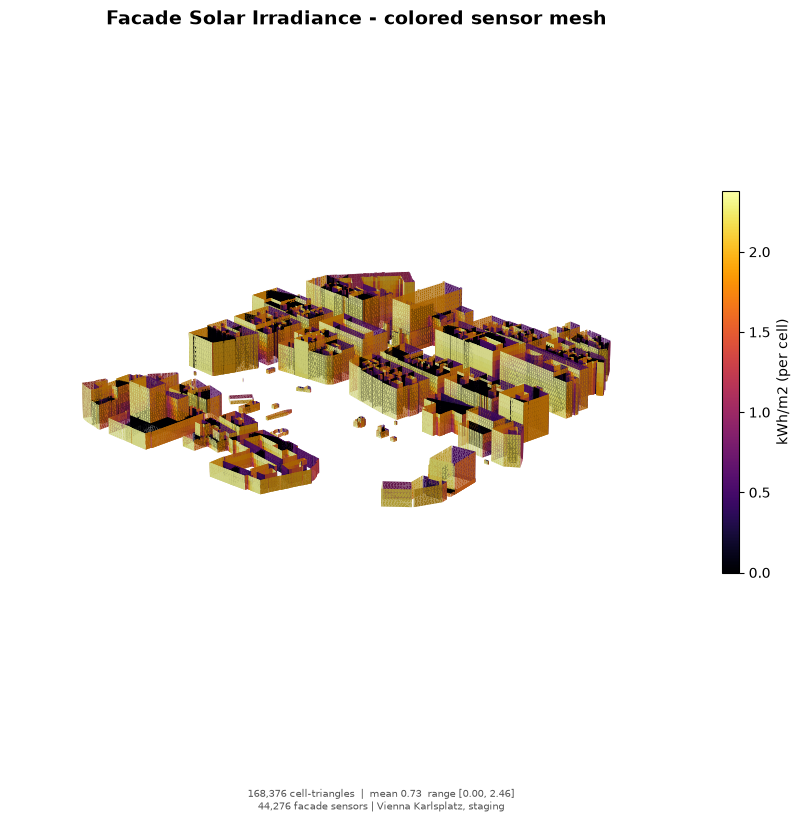

In [7]:
tris, values, normals = ia.reconstruct_cells(fac_res["surfaces"])
faces = ia.building_faces(buildings)
fig, ax = ir.surface_mesh(
    tris,
    values,
    normals=normals,
    context_faces=faces,
    title="Facade Solar Irradiance - colored sensor mesh",
    cbar_label="kWh/m2 (per cell)",
    cmap="inferno",
    zmax=45,
    note=f"{fac_res['sensor-count']:,} facade sensors | Vienna Karlsplatz, staging",
)
fig

## Advanced run 2 - roofs + facades together (`analysis-surfaces:"all"`)

`"all"` synthesizes on **both** facades and roof caps, so the buildings render
as closed, colored solids rather than open-topped shells.

[solar-radiation/all] Succeeded in 1.5s  keys=['aggregates', 'max-legend', 'min-legend', 'sensor-count', 'surfaces']  sensors=54019


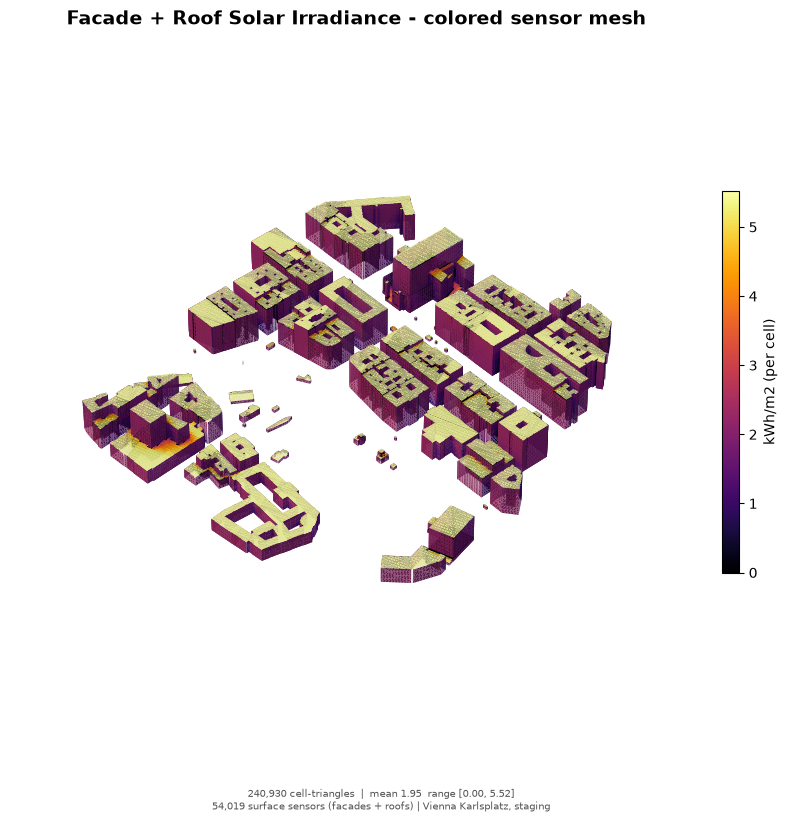

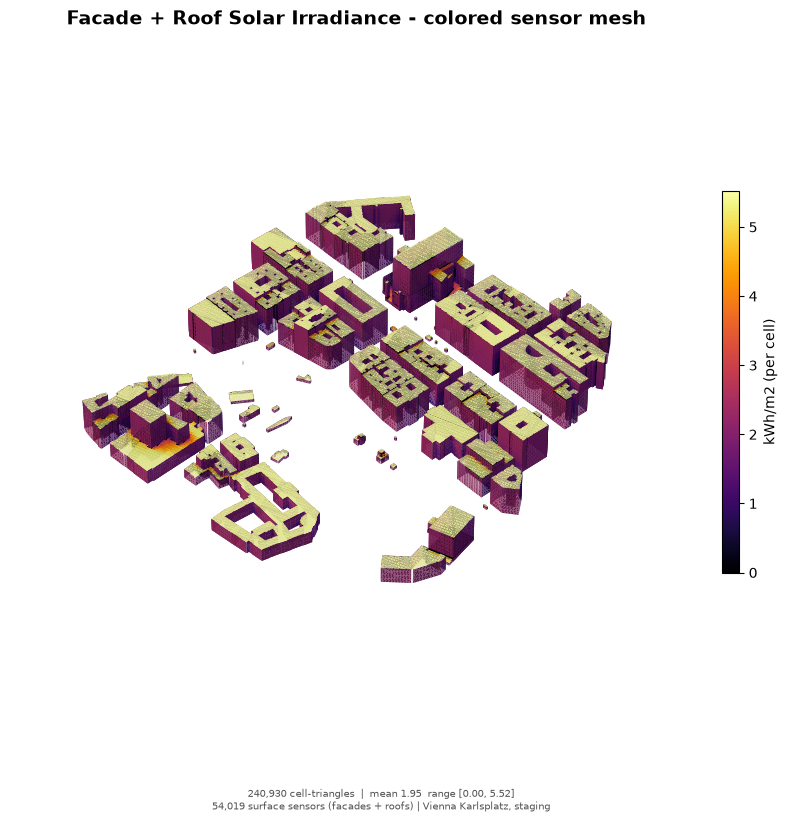

In [8]:
body = sr_body()
body["analysis-surfaces"] = "all"
body["surface-grid-size"] = 4.0
body["surface-offset"] = 0.1
body["partial-cells"] = True
body["min-coverage"] = 0.25
roof_res, info = ia.run_job("solar-radiation", body, label="all")
rt, rv, rn = ia.reconstruct_cells(roof_res["surfaces"])
fig, ax = ir.surface_mesh(
    rt,
    rv,
    normals=rn,
    context_faces=ia.building_faces(buildings),
    title="Facade + Roof Solar Irradiance - colored sensor mesh",
    cbar_label="kWh/m2 (per cell)",
    cmap="inferno",
    zmax=45,
    elev=42,
    note=f"{roof_res['sensor-count']:,} surface sensors (facades + roofs) | Vienna Karlsplatz, staging",
)
fig

## Advanced run 3 - bring-your-own sensor points

Instead of synthesizing a grid, send explicit `sensor-points` (tile-local
meters) and optional `sensor-normals`. The result is a **flat** `output` list,
one value per point, in input order, plus `sensor-count`.

In [9]:
# A vertical mast of points at the AOI centre, 2 m -> 40 m.
mast = [[160.0, 230.0, z] for z in range(2, 42, 2)]
body = sr_body()
body["sensor-points"] = mast
body["sensor-normals"] = [[0.0, -1.0, 0.0]] * len(mast)  # facing south
byo_res, info = ia.run_job("solar-radiation", body, label="sensor-points")
print("keys:", sorted(byo_res), "| sensor-count:", byo_res["sensor-count"])
print("per-point kWh/m2 (z = 2..40 m):")
for (x, y, z), val in zip(mast, byo_res["output"]):
    print(f"  z={z:2d} m : {val:.3f}")

[solar-radiation/sensor-points] Succeeded in 0.2s  keys=['max-legend', 'min-legend', 'output', 'sensor-count']  sensors=20
keys: ['max-legend', 'min-legend', 'output', 'sensor-count'] | sensor-count: 20
per-point kWh/m2 (z = 2..40 m):
  z= 2 m : 0.897
  z= 4 m : 0.897
  z= 6 m : 1.016
  z= 8 m : 1.096
  z=10 m : 1.216
  z=12 m : 1.564
  z=14 m : 1.602
  z=16 m : 1.734
  z=18 m : 1.946
  z=20 m : 1.997
  z=22 m : 2.094
  z=24 m : 2.131
  z=26 m : 2.205
  z=28 m : 2.271
  z=30 m : 2.271
  z=32 m : 2.271
  z=34 m : 2.271
  z=36 m : 2.271
  z=38 m : 2.271
  z=40 m : 2.271


## Summary

* **Standard**: 512x512 ground grid (`output`).
* **`analysis-surfaces`**: per-facade / per-roof colored mesh (`surfaces` +
  `aggregates`), reconstructed with the frame `origin/u/v/grid-size`.
* **`sensor-points`**: flat per-point values in input order.

All advanced fields are direct-API today (not on the SDK's typed models). The
same pattern works for daylight (`02`), direct-sun-hours (`03`) and SVF (`04`).